In [15]:

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

In [16]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [17]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.2

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [18]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

KeyboardInterrupt: 

Body is not plunging, Fisher should be stable.
waveform shape:  (2, 631163)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 41.71176563349507
calculating stable deltas...
Gamma_ii for m1: 21.40761398570681
Gamma_ii for m1: 21.407613985615114
Gamma_ii for m1: 21.407613986369892
Gamma_ii for m1: 21.407613986901524
Gamma_ii for m1: 21.40761398548391
Gamma_ii for m1: 21.407614033115657
Gamma_ii for m1: 21.407613951310324
Gamma_ii for m1: 21.407613614076677
Gamma_ii for m1: 21.407611538373388
Gamma_ii for m1: 21.407616168579477
[np.float64(4.283314343740312e-12), np.float64(3.525743570747342e-11), np.float64(2.483376372232189e-11), np.float64(6.622010613687585e-11), np.float64(2.2249909476824323e-09), np.float64(3.821319483433589e-09), np.float64(1.575297710940775e-08), np.float64(9.69609937815678e-08), np.f

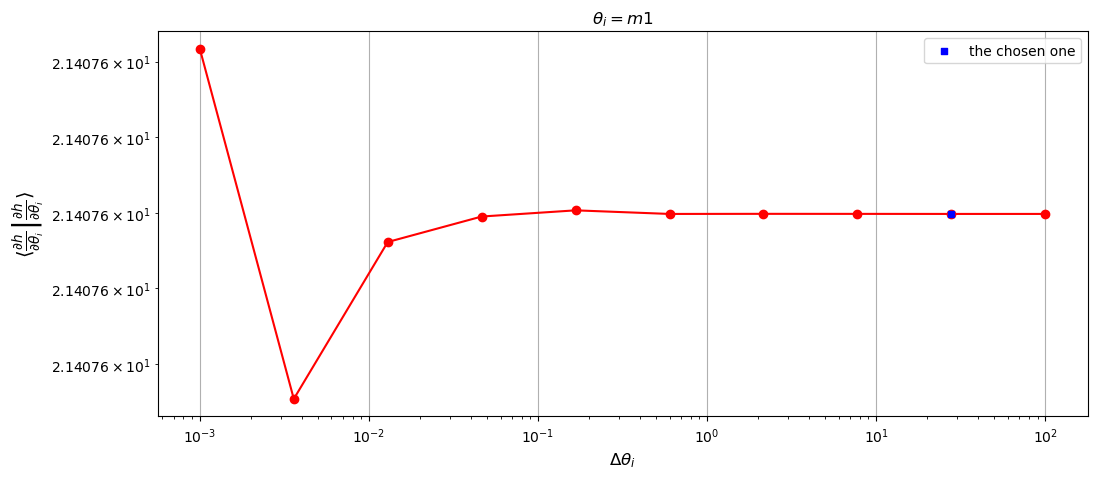

Gamma_ii for m2: 250672323.61392573
Gamma_ii for m2: 250672323.61278355
Gamma_ii for m2: 250672323.93133524
Gamma_ii for m2: 250672322.53927988
Gamma_ii for m2: 250672326.2285006
Gamma_ii for m2: 250672322.2756209
Gamma_ii for m2: 250672326.91748673
Gamma_ii for m2: 250672469.3409588
Gamma_ii for m2: 250671388.34166878
Gamma_ii for m2: 250673224.96156
[np.float64(4.5564424067523e-12), np.float64(1.27078922950276e-09), np.float64(5.553287049649708e-09), np.float64(1.471730358909706e-08), np.float64(1.5769111089728248e-08), np.float64(1.8517663584064325e-08), np.float64(5.681655925403335e-07), np.float64(4.312415936939144e-06), np.float64(7.326749362672985e-06)]
0


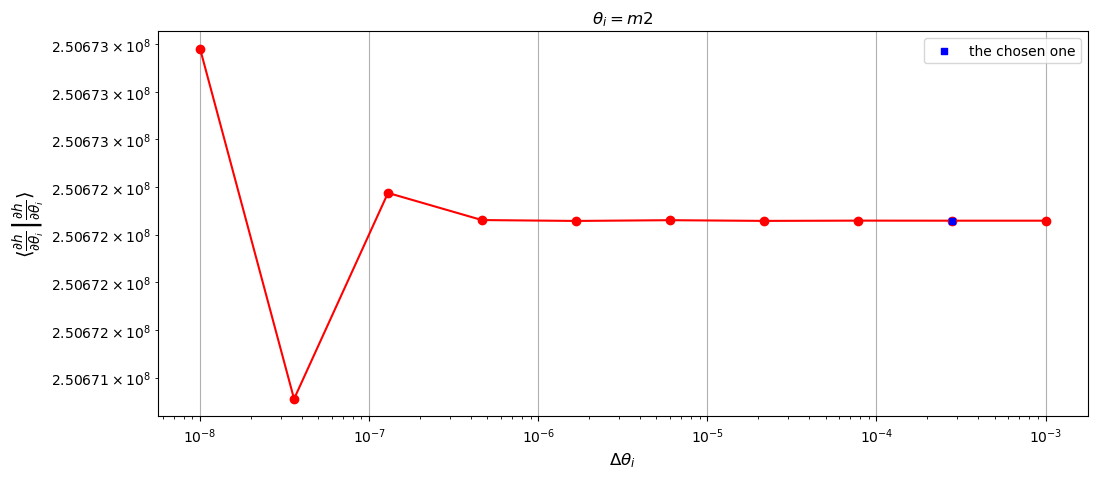

Gamma_ii for a: 41882488990.64592
Gamma_ii for a: 41882492371.695244
Gamma_ii for a: 41882430723.38428
Gamma_ii for a: 41882338854.875565
Gamma_ii for a: 41881923876.700294
Gamma_ii for a: 41882472530.349976
Gamma_ii for a: 41894969912.758255
Gamma_ii for a: 41861377144.050766
Gamma_ii for a: 41928086080.53152
Gamma_ii for a: 41826352263.087875
[np.float64(8.072703252781115e-08), np.float64(1.471937275409173e-06), np.float64(2.19349041205883e-06), np.float64(9.908288274716548e-06), np.float64(1.3099839062355058e-05), np.float64(0.00029830269443572503), np.float64(0.0008024764353043539), np.float64(0.0015910322343982695), np.float64(0.0024322899784264156)]
0


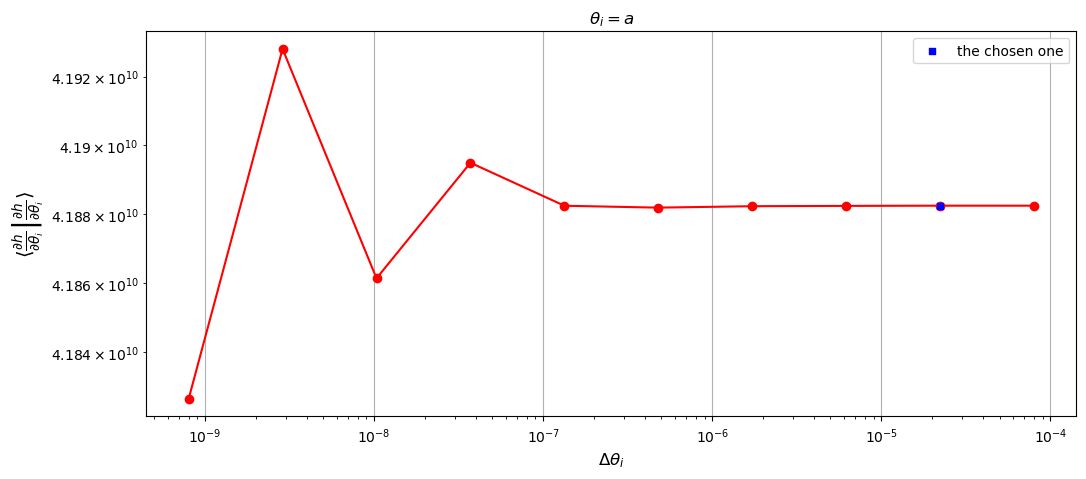

Gamma_ii for p0: 723659603258.8575
Gamma_ii for p0: 723659536722.998
Gamma_ii for p0: 723659596211.6165
Gamma_ii for p0: 723659750224.217
Gamma_ii for p0: 723660235867.2512
Gamma_ii for p0: 723659495451.945
Gamma_ii for p0: 723634493470.342
Gamma_ii for p0: 723630903058.7097
Gamma_ii for p0: 723622053066.2678
Gamma_ii for p0: 723618576463.0071
[np.float64(9.194359518616952e-08), np.float64(8.220525053440616e-08), np.float64(2.1282460512446437e-07), np.float64(6.710926068746635e-07), np.float64(1.0231542748043467e-06), np.float64(3.455056638193543e-05), np.float64(4.961661555840051e-06), np.float64(1.223013091487977e-05), np.float64(4.8044693348470425e-06)]
1


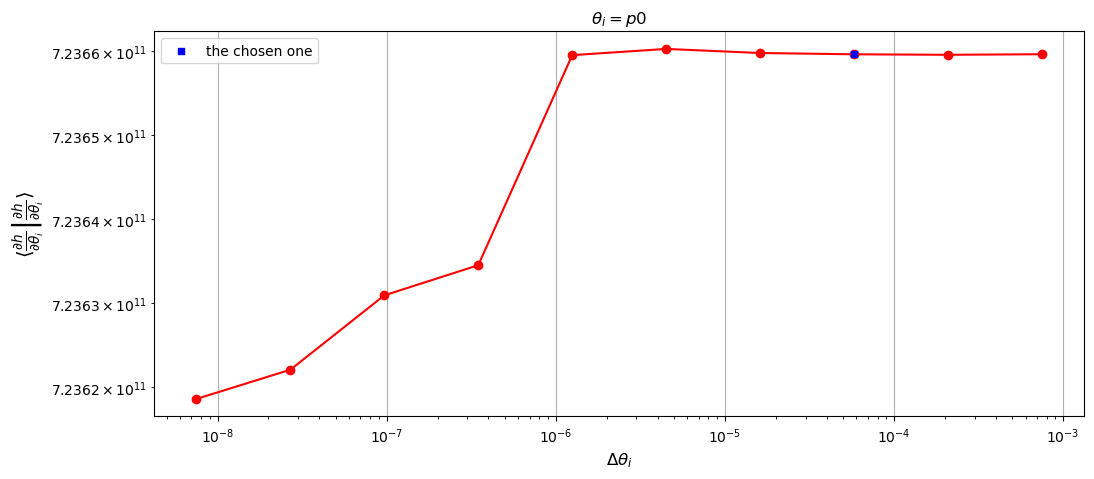

Gamma_ii for e0: 20518514407378.324
Gamma_ii for e0: 20518516433649.613
Gamma_ii for e0: 20518507752375.426
Gamma_ii for e0: 20518429492729.75
Gamma_ii for e0: 20518284698850.87
Gamma_ii for e0: 20518836233388.176
Gamma_ii for e0: 20520088515278.72
Gamma_ii for e0: 20524173148686.65
Gamma_ii for e0: 20495598093647.59
Gamma_ii for e0: 20543481246531.19
[np.float64(9.87533039055148e-08), np.float64(4.230948123649474e-07), np.float64(3.814114803645709e-06), np.float64(7.056821805724113e-06), np.float64(2.6879425861747096e-05), np.float64(6.102711933286996e-05), np.float64(0.00019901573516938807), np.float64(0.0013942044973996222), np.float64(0.0023308198016189067)]
0


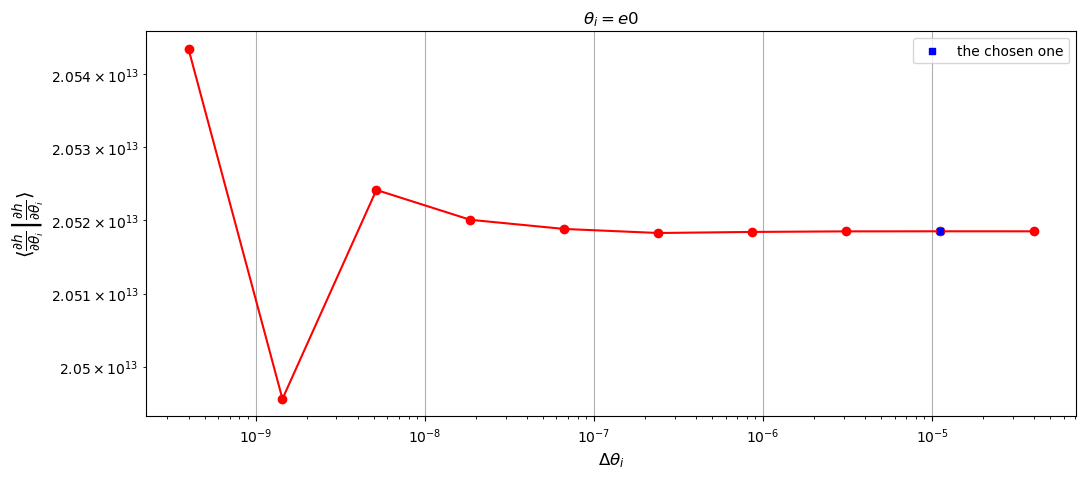

Gamma_ii for qS: 5356.219367909812
Gamma_ii for qS: 5356.219374661335
Gamma_ii for qS: 5356.219374661523
Gamma_ii for qS: 5356.219374661649
Gamma_ii for qS: 5356.219374660839
Gamma_ii for qS: 5356.219374660225
Gamma_ii for qS: 5356.219374649627
Gamma_ii for qS: 5356.219374663596
Gamma_ii for qS: 5356.21937476883
Gamma_ii for qS: 5356.2193748413165
[np.float64(1.2605015754577088e-09), np.float64(3.514893436919642e-14), np.float64(2.360242452810718e-14), np.float64(1.5129323924134303e-13), np.float64(1.146160903343639e-13), np.float64(1.978698223213312e-12), np.float64(2.6079830095472408e-12), np.float64(1.9647065700680017e-11), np.float64(1.35331887397629e-11)]
2


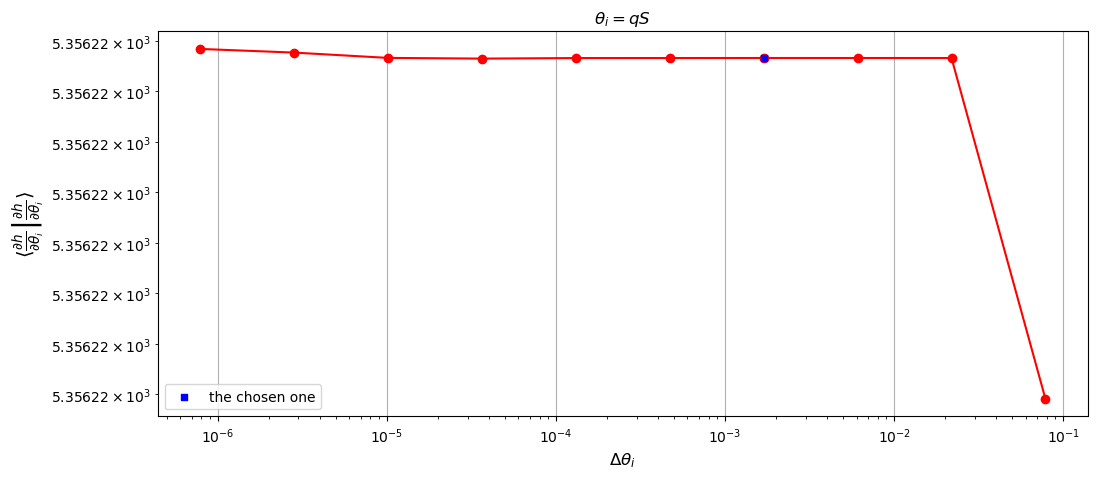

Gamma_ii for phiS: 103111.93247663214
Gamma_ii for phiS: 103111.93247530714
Gamma_ii for phiS: 103111.93247530708
Gamma_ii for phiS: 103111.93247530708
Gamma_ii for phiS: 103111.9324753071
Gamma_ii for phiS: 103111.9324753071
Gamma_ii for phiS: 103111.93247530719
Gamma_ii for phiS: 103111.93247530719
Gamma_ii for phiS: 103111.93247530413
Gamma_ii for phiS: 103111.93247531104
[np.float64(1.2850069875334671e-11), np.float64(5.645094560458053e-16), np.float64(0.0), np.float64(1.411273640114513e-16), np.float64(0.0), np.float64(8.467641840687071e-16), np.float64(0.0), np.float64(2.963674644240563e-14), np.float64(6.703549790543681e-14)]
2


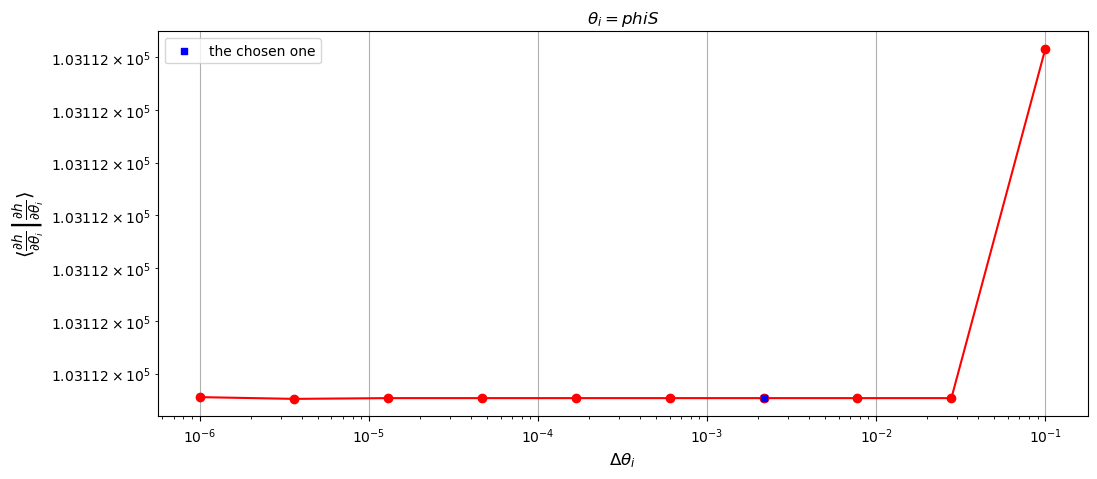

Gamma_ii for dev0p: 12301758905.187817
Gamma_ii for dev0p: 12301780694.128899
Gamma_ii for dev0p: 12301710888.837635
Gamma_ii for dev0p: 12302353717.368023
Gamma_ii for dev0p: 12302364484.794237
Gamma_ii for dev0p: 12306288330.03783
Gamma_ii for dev0p: 12296990167.369047
Gamma_ii for dev0p: 12334560954.363848
Gamma_ii for dev0p: 12369916293.66365
Gamma_ii for dev0p: 11120219456.950924
[np.float64(1.771202204279226e-06), np.float64(5.674437636712831e-06), np.float64(5.2252483155345804e-05), np.float64(8.752322553543844e-07), np.float64(0.0003188487981397031), np.float64(0.0007561332116420272), np.float64(0.0030459768396951647), np.float64(0.0028581712649028315), np.float64(0.1123805911880253)]
3


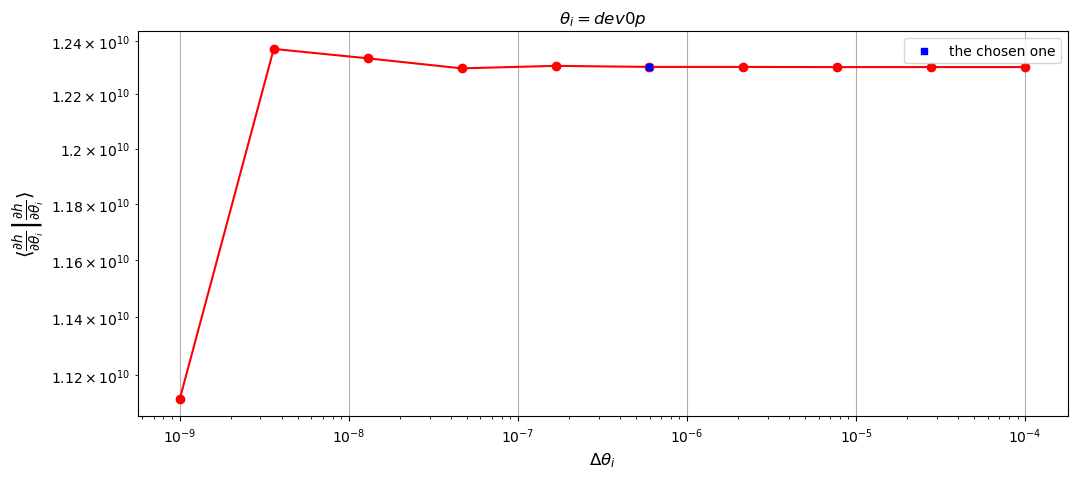

Gamma_ii for dev0e: 2256618890.6316056
Gamma_ii for dev0e: 2256641061.2718453
Gamma_ii for dev0e: 2256606438.9322524
Gamma_ii for dev0e: 2256452849.061381
Gamma_ii for dev0e: 2256228451.444789
Gamma_ii for dev0e: 2258225682.4511347
Gamma_ii for dev0e: 2251978085.67279
Gamma_ii for dev0e: 2213146950.4711285
Gamma_ii for dev0e: 2261879662.495026
Gamma_ii for dev0e: 2413727957.0344296
[np.float64(9.824619705900495e-06), np.float64(1.5342657450412904e-05), np.float64(6.806695337570773e-05), np.float64(9.945695722799528e-05), np.float64(0.000884424892457119), np.float64(0.0027742706814476523), np.float64(0.017545665096208512), np.float64(0.02154522755208902), np.float64(0.0629102770661729)]
0


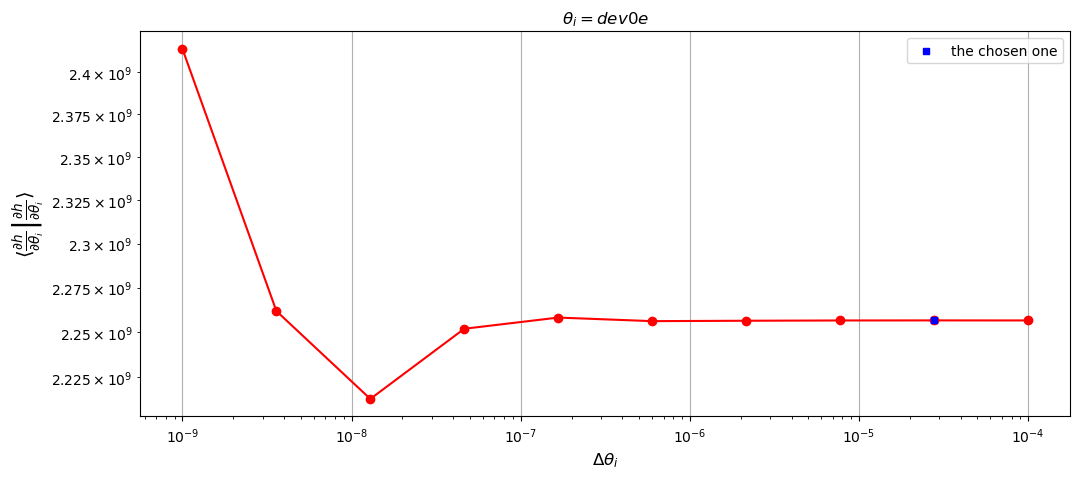

stable deltas: {'m1': 27.825594022071243, 'm2': 0.0002782559402207126, 'a': 2.2260475217657015e-05, 'p0': 5.806977620108459e-05, 'e0': 1.1130237608828506e-05, 'qS': 0.0016920890487107918, 'phiS': 0.002154434690031882, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 5.994842503189409e-07, 'dev0e': 2.782559402207126e-05}
Time taken to compute stable deltas is 43.35230827331543 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 4.249499797821045 seconds


In [ ]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [ ]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])

In [ ]:
chi2=0
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

[0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [ ]:
chi2=0
deviation_included=True
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_):
    add_args__ = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,\
                dev0p_,dev0e_,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    waveform_temp=superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args__, dt=dt, T=T,use_gpu=use_gpu)
    diff_inner=inner_product(waveform_temp,waveform_true,PSD,dt,use_gpu=use_gpu)
    return -0.5 * diff_inner



In [ ]:
import pandas as pd
print(std)
pd.DataFrame(fisher_)

[0.02468575 0.12933579 0.01639426 0.09579294 0.0064008  0.0465041
 0.0542928  0.22476464 0.06746977 0.02272099 0.03471389]


,0,1,2,3,4,5,6,7,8,9,10
0,2.140761e+13,-7.105573e+10,-3.769059e+11,3.933035e+12,2.094794e+13,-2.735935e+08,1.262623e+09,-3.311320e+08,-3.564958e+08,-4.965752e+11,-2.142108e+11
1,-7.105573e+10,2.506723e+08,1.015880e+09,-1.309767e+10,-6.898063e+10,8.156336e+05,-3.763839e+06,9.870968e+05,1.035339e+06,1.755882e+09,7.516214e+08
2,-3.769059e+11,1.015880e+09,4.188249e+10,-6.308499e+10,-3.783517e+11,3.670234e+06,-1.690206e+07,4.416499e+06,1.186229e+07,6.807146e+09,3.355218e+09
3,3.933035e+12,-1.309767e+10,-6.308499e+10,7.236596e+11,3.846838e+12,-5.044933e+07,2.328278e+08,-6.106359e+07,-6.449992e+07,-9.158484e+10,-3.943394e+10
4,2.094794e+13,-6.898063e+10,-3.783517e+11,3.846838e+12,2.051852e+13,-2.710884e+08,1.251062e+09,-3.280995e+08,-3.544603e+08,-4.819185e+11,-2.081108e+11
5,-2.735935e+08,8.156336e+05,3.670234e+06,-5.044933e+07,-2.710884e+08,5.356219e+03,-2.226894e+04,5.841132e+03,5.835733e+03,5.697251e+06,2.461212e+06
6,1.262623e+09,-3.763839e+06,-1.690206e+07,2.328278e+08,1.251062e+09,-2.226894e+04,1.031119e+05,-2.696129e+04,-2.692622e+04,-2.629312e+07,-1.135834e+07
7,-3.311320e+08,9.870968e+05,4.416499e+06,-6.106359e+07,-3.280995e+08,5.841132e+03,-2.696129e+04,7.073114e+03,7.059534e+03,6.895671e+06,2.978700e+06
8,-3.564958e+08,1.035339e+06,1.186229e+07,-6.449992e+07,-3.544603e+08,5.835733e+03,-2.692622e+04,7.059534e+03,8.963091e+03,7.183274e+06,3.173721e+06
9,-4.965752e+11,1.755882e+09,6.807146e+09,-9.158484e+10,-4.819185e+11,5.697251e+06,-2.629312e+07,6.895671e+06,7.183274e+06,1.230236e+10,5.261920e+09


In [ ]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
        m1_ = 10**logm1_

        loglike = loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_)
        log_likes[i] = loglike 
    return log_likes

n=2
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]
dev0plim = [params_truth_in[9] - n*std[9], params_truth_in[9] + n*std[9]]
dev0elim = [params_truth_in[10] - n*std[10], params_truth_in[10] + n*std[10]]

def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]

    # Linear in others 
    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    transformed[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    transformed[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    transformed[:, 7] = (Phi_phi0lim[1] - Phi_phi0lim[0]) * u[:, 7] + Phi_phi0lim[0]
    transformed[:, 8] = (Phi_r0lim[1] - Phi_r0lim[0]) * u[:, 8] + Phi_r0lim[0]
    transformed[:, 9] = (dev0plim[1] - dev0plim[0]) * u[:, 9] + dev0plim[0]
    transformed[:, 10] = (dev0elim[1] - dev0elim[0]) * u[:, 10] + dev0elim[0]

    return transformed

    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (x[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 7] = (x[:, 7] - Phi_phi0lim[0]) / (Phi_phi0lim[1] - Phi_phi0lim[0])
    u[:, 8] = (x[:, 8] - Phi_r0lim[0]) / (Phi_r0lim[1] - Phi_r0lim[0])
    u[:, 9] = (x[:, 9] - dev0plim[0]) / (dev0plim[1] - dev0plim[0])
    u[:, 10] = (x[:, 10] - dev0elim[0]) / (dev0elim[1] - dev0elim[0])
    
    return u

In [ ]:
def analyze_results(sampler, savepath):
    """
    Analyze and summarize the sampling results.
    
    Parameters:
    ----------
    sampler : Sampler
        The sampler instance after running
    savepath : str
        Path where results are saved
    """
    print("\n" + "="*60)
    print("ANALYSIS RESULTS")
    print("="*60)
    
    # Get samples and weights
    samples, weights = sampler.get_samples_with_weights(flatten=True)
    
    # Basic statistics
    print(f"Total samples generated: {len(samples):,}")
    print(f"Effective sample size: {1/np.sum(weights**2):.1f}")
    print(f"Weight coefficient of variation: {np.std(weights)/np.mean(weights):.3f}")
    
    # Transform samples to the coordinate system used in log_density
    transformed_samples = (samples * 1.4) - 0.2
    
    # Compute weighted statistics
    weighted_mean = np.average(transformed_samples, weights=weights, axis=0)
    weighted_std = np.sqrt(np.average((transformed_samples - weighted_mean)**2, 
                                    weights=weights, axis=0))
    
    print(f"\nWeighted mean (transformed coordinates): {weighted_mean}")
    print(f"Weighted std (transformed coordinates): {weighted_std}")
    
    # Find best samples
    log_densities = sampler.log_density_func(samples)
    best_idx = np.argmax(log_densities)
    best_sample = samples[best_idx]
    best_log_density = log_densities[best_idx]
    
    print(f"\nBest sample found:")
    print(f"  Coordinates (unit cube): {best_sample}")
    print(f"  Coordinates (transformed): {(best_sample * 1.4) - 0.2}")
    print(f"  Log-density: {best_log_density:.2f}")
    
    # Mode detection (simple clustering based on high-density samples)
    high_likelihood_threshold = np.percentile(log_densities, 95)
    high_likelihood_mask = log_densities >= high_likelihood_threshold
    high_likelihood_samples = transformed_samples[high_likelihood_mask]
    
    print(f"\nHigh-density regions (top 5%):")
    print(f"  Number of samples: {np.sum(high_likelihood_mask)}")
    
    if np.sum(high_likelihood_mask) > 0:
        # Simple mode detection: find cluster centers
        try:
            from sklearn.cluster import KMeans
            n_clusters = min(10, np.sum(high_likelihood_mask))
            if n_clusters >= 2:
                kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
                cluster_labels = kmeans.fit_predict(high_likelihood_samples)
                cluster_centers = kmeans.cluster_centers_
                
                print(f"  Detected {n_clusters} high-density clusters:")
                for i, center in enumerate(cluster_centers):
                    cluster_size = np.sum(cluster_labels == i)
                    print(f"    Cluster {i+1}: center = {center}, samples = {cluster_size}")
        except ImportError:
            print("  (sklearn not available for clustering analysis)")
    
    # Save additional analysis results
    analysis_file = os.path.join(savepath, 'analysis_summary.txt')
    with open(analysis_file, 'w') as f:
        f.write(f"Multimodal Sampling Analysis Results\n")
        f.write(f"=====================================\n\n")
        f.write(f"Total samples: {len(samples)}\n")
        f.write(f"Effective sample size: {1/np.sum(weights**2):.1f}\n")
        f.write(f"Best log-density: {best_log_density:.6f}\n")
        f.write(f"Best sample (unit cube): {best_sample}\n")
        f.write(f"Best sample (transformed): {(best_sample * 1.4) - 0.2}\n")
    
    print(f"\nDetailed analysis saved to: {analysis_file}")

def visualize_marginal_distributions(sampler, savepath):
    """
    Create marginal distribution plots for each dimension.
    
    Parameters:
    ----------
    sampler : Sampler
        The sampler instance after running
    savepath : str
        Path where results are saved
    """
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        from scipy.stats import norm
    except ImportError:
        print("Matplotlib/seaborn not available. Skipping visualization.")
        return
    
    print("\nCreating marginal distribution plots...")
    
    # Get samples and weights
    samples, weights = sampler.get_samples_with_weights(flatten=True)
    ndim = samples.shape[1]
    
    # Visualization parameters
    bin_num = 50
    decay = 3  # For exponential smoothing
    

In [20]:
def main():
    
    config = SamplerConfig(
        merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
        alpha=10000,                    # Use recent samples for weighting
        trail_size=int(1e3),          # Maximum trials per iteration
        boundary_limiting=True,        # Enable boundary constraints
        use_beta=True,                # Use beta correction for boundaries
        integral_num=int(1e5),        # MC samples for beta estimation
        gamma=500,                    # Covariance update frequency
        exclude_scale_z=10,       # No exclusion based on weights
        use_pool=False,               # Set to True for multiprocessing
        n_pool=4                     # Number of processes (if use_pool=True)
    )
    
    ndim = 11
    n_seed = 10  # Number of initial processes
    init_cov_list = [np.eye(ndim) * 0.05] * n_seed
    sigma= 0.01

    savepath = './fisher_deviation_results/'

    init_cov_list = []
    for i in range(n_seed):
        init_cov_list.append(sigma**2 * np.eye(ndim))
    
    # Create save directory
    os.makedirs(savepath, exist_ok=True)
    
    print(f"Problem dimension: {ndim}")
    print(f"Number of processes: {n_seed}")
    print(f"Initial covariance scale: {sigma}")
    print(f"Save path: {savepath}")
    print(f"Multiprocessing: {config.use_pool}")

    # Initialize sampler
    print("\nInitializing sampler...")
    sampler = Sampler(
        ndim=ndim, 
        n_seed=n_seed,
        log_density_func=log_density,
        init_cov_list=init_cov_list,
        prior_transform=prior_transform,
        config=config
    )
   # Prepare initial samples using Latin Hypercube Sampling
    print("Preparing LHS samples...")
    sampler.prepare_lhs_samples(lhs_num=int(1e4), batch_size=10)
    
    # Run the sampling process
    print("Starting sampling process...")
    print("(This may take several minutes for 10,000 iterations)")
    
    try:
        sampler.run_sampling(
            num_iterations=10000, 
            savepath=savepath,
            print_iter=100  # Print progress every 100 iterations
        )
        
        print("\nSampling completed successfully!")
        
       # Analyze results
        analyze_results(sampler, savepath)
        
    #Create visualizations
        visualize_marginal_distributions(sampler, savepath)
        
    except KeyboardInterrupt:
        print("\nSampling interrupted by user.")
        print("Partial results have been saved.")
        if hasattr(sampler, 'searched_points_list'):
            analyze_results(sampler, savepath)
            try:
                visualize_marginal_distributions(sampler, savepath)
            except:
                print("Could not create visualizations with partial results.")
    
    except Exception as e:
        print(f"\nError during sampling: {e}")
        raise
    
    
    print(f"\nResults saved to: {savepath}")
    print("Example completed!")

if __name__ == "__main__":

    main()



Problem dimension: 11
Number of processes: 10
Initial covariance scale: 0.01
Save path: ./fisher_deviation_results/
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...


Computing LHS densities:   0%|          | 0/1000 [00:00<?, ?it/s]

Starting sampling process...
(This may take several minutes for 10,000 iterations)


Sampling:   0%|          | 0/9999 [00:00<?, ?it/s]

/home/svu/e1583490/scratch/parismc/parismc/sampler.py:765: RuntimeWarning: divide by zero encountered in log
  logZ = c_term - np.log(Nsum) + np.log(wsum)
/home/svu/e1583490/scratch/parismc/parismc/sampler.py:765: RuntimeWarning: invalid value encountered in scalar add
  logZ = c_term - np.log(Nsum) + np.log(wsum)



Sampling completed successfully!

ANALYSIS RESULTS
Total samples generated: 10,000
Effective sample size: 302.5
Weight coefficient of variation: 9.974

Weighted mean (transformed coordinates): [19.14738259 13.81622533  0.91926811 10.29471201  0.35871535  0.88823724
  1.20323075  1.03561581  0.34835788 -0.1978977  -0.19982726]
Weighted std (transformed coordinates): [0.03784699 0.21413976 0.02767735 0.13231048 0.01005503 0.07473691
 0.08433222 0.36168161 0.11427282 0.03433225 0.05772503]

Best sample found:
  Coordinates (unit cube): [ 1.37395954e+01  1.02986893e+01  7.62115004e-01  7.50765922e+00
  4.17729451e-01  8.56649609e-01  1.09156164e+00  5.84324383e-01
 -1.35031994e-03 -9.89602655e-02  7.60856375e-02]
  Coordinates (transformed): [19.03543357 14.21816498  0.86696101 10.31072291  0.38482123  0.99930945
  1.3281863   0.61805414 -0.20189045 -0.33854437 -0.09348011]
  Log-density: 0.00

High-density regions (top 5%):
  Number of samples: 500
  Detected 10 high-density clusters:
  

In [ ]:

print("Preparing external LHS samples...")
lhs_num = 1000
batch_size = 100
ndim=11
xlimits=[]
for i in range(ndim):
     xlimits.append([params_truth_in[i] - 0.25*std[i], params_truth_in[i] + 0.25*std[i]])
xlimits = np.array(xlimits, dtype=np.float32)
sampling = LHS(xlimits=xlimits)
external_lhs_points = sampling(lhs_num).astype(np.float32)
# Compute log-densities for the LHS points in batches
external_lhs_log_densities = np.zeros(lhs_num, dtype=float)
for i in range(0, lhs_num, batch_size):
    end = min(i + batch_size, lhs_num)
    external_lhs_log_densities[i:end] = log_density(external_lhs_points[i:end])
# Run sampling
print("Running sampling with external LHS...")
sampler.run_sampling(
        num_iterations=100,
        savepath='./basic_results',
        print_iter=20,
        stop_dlogZ=0.1,
        external_lhs_points=external_lhs_points,
        external_lhs_log_densities=external_lhs_log_densities,
    )

In [ ]:
params_truth_in